In [1]:
import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt
%matplotlib inline

In [2]:
words = open('names.txt', 'r').read().splitlines()

In [5]:
chars = sorted(list(set(''.join(words))))
stoi = {s:i+1 for i,s in enumerate(chars)}
stoi['.'] = 0
itos = {i:s for s,i in stoi.items()}

In [10]:
ctx_size = 3

def build_dataset(words):  
  X, Y = [], []
  for w in words:

    context = [0] * block_size
    for ch in w + '.':
      ix = stoi[ch]
      X.append(context)
      Y.append(ix)
      context = context[1:] + [ix] 

  X = torch.tensor(X)
  Y = torch.tensor(Y)
  return X, Y

import random
random.shuffle(words)
n1 = int(0.8*len(words))
n2 = int(0.9*len(words))

Xtr, Ytr = build_dataset(words[:n1])
Xdev, Ydev = build_dataset(words[n1:n2])
Xte, Yte = build_dataset(words[n2:])

Xtr.shape, Ytr.shape

(torch.Size([182587, 3]), torch.Size([182587]))

In [22]:
# --- model draft ---

In [16]:
C = torch.randn((27, 2))
emb = C[Xtr]
emb.shape

torch.Size([182587, 3, 2])

In [19]:
emb = emb.view(-1,6)
emb.shape

torch.Size([182587, 6])

In [20]:
W1 = torch.randn((6, 100))
b1 = torch.randn(100)
h = torch.tanh(emb @ W1 + b1)
h.shape

torch.Size([182587, 100])

In [23]:
W2 = torch.randn((100, 27))
b2 = torch.randn(27)
logits = h @ W2 + b2
logits.shape

torch.Size([182587, 27])

In [24]:
# --- model ---

In [87]:
C = torch.randn((27, 10))*0.01
W1 = torch.randn((30, 200))*0.01
b1 = torch.randn(200)*0.01
W2 = torch.randn((200, 27))*0.01
b2 = torch.randn(27)*0.01

params = [C, W1, b1, W2, b2]
for p in params:
  p.requires_grad = True

sum(p.numel() for p in params)

optimizer = torch.optim.Adam(params, lr=0.1)

In [88]:
for i in range(5001):
    lr = 0.01 if i < 4000 else 0.001

    for group in optimizer.param_groups:
        group["lr"] = lr

    # forward
    emb = C[Xtr]
    h = torch.tanh(emb.view(-1, 30) @ W1 + b1)
    logits = h @ W2 + b2
    loss = F.cross_entropy(logits, Ytr)

    if i%100 == 0:
        print(i, loss.item())

    # backward
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

0 3.2972514629364014
100 2.342383623123169
200 2.270892381668091
300 2.1781363487243652
400 2.1125075817108154
500 2.0669875144958496
600 2.038600206375122
700 2.023616075515747
800 2.0123326778411865
900 2.0059142112731934
1000 2.0007197856903076
1100 1.9970635175704956
1200 1.9947317838668823
1300 1.992403268814087
1400 1.9906491041183472
1500 1.989885687828064
1600 1.987884521484375
1700 1.9866496324539185
1800 1.9850566387176514
1900 1.9837172031402588
2000 1.9825687408447266
2100 1.9816443920135498
2200 1.9807744026184082
2300 1.9798704385757446
2400 1.9792492389678955
2500 1.978463053703308
2600 1.9776556491851807
2700 1.9768931865692139
2800 1.9764328002929688
2900 1.9757757186889648
3000 1.9749306440353394
3100 1.974539041519165
3200 1.9747382402420044
3300 1.9736170768737793
3400 1.9740471839904785
3500 1.9720962047576904
3600 1.9715514183044434
3700 1.9710640907287598
3800 1.9704850912094116
3900 1.9700607061386108
4000 1.9696440696716309
4100 1.969428300857544
4200 1.9693785

In [89]:
emb = C[Xdev]
h = torch.tanh(emb.view(-1, 30) @ W1 + b1)
logits = h @ W2 + b2 
loss = F.cross_entropy(logits, Ydev)
loss.item()

2.112926959991455

In [92]:
emb = C[Xte]
h = torch.tanh(emb.view(-1, 30) @ W1 + b1)
logits = h @ W2 + b2 
loss = F.cross_entropy(logits, Yte)
loss.item()

2.140329122543335

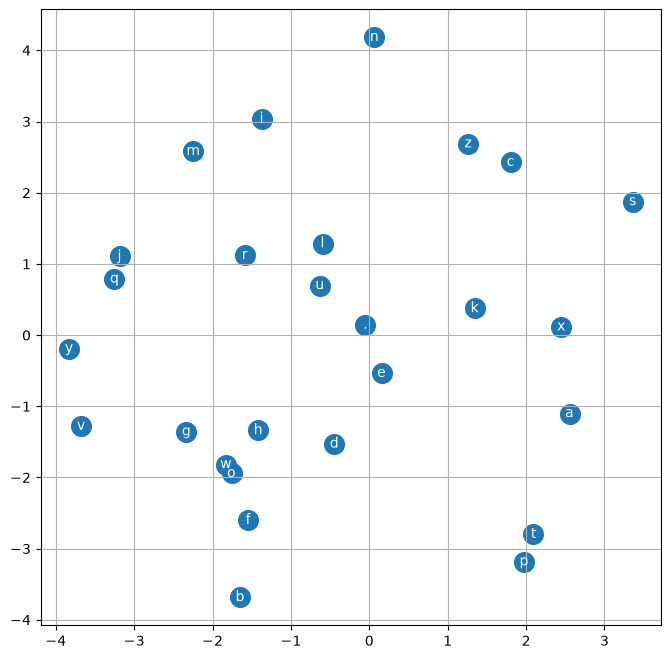

In [90]:
plt.figure(figsize=(8,8))
plt.scatter(C[:,0].data, C[:,1].data, s=200)
for i in range(C.shape[0]):
    plt.text(C[i,0].item(), C[i,1].item(), itos[i], ha="center", va="center", color='white')
plt.grid('minor')

In [78]:
batch_size = 128

for i in range(200_001):

    # learning rate decay
    lr = 0.01 if i < 100000 else 0.001
    for group in optimizer.param_groups:
        group["lr"] = lr

    # minibatch
    ix = torch.randint(0, Xtr.shape[0], (batch_size,))
    Xb, Yb = Xtr[ix], Ytr[ix]

    # forward
    emb = C[Xb]
    h = torch.tanh(emb.view(-1, 30) @ W1 + b1)
    logits = h @ W2 + b2
    loss = F.cross_entropy(logits, Yb)

    if i%5000 == 0:
        print(i, loss.item())
    
    # backward
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

0 2.289996862411499
5000 2.15189266204834
10000 2.1779494285583496
15000 2.2619211673736572
20000 2.227268934249878
25000 2.187847852706909
30000 2.3260958194732666
35000 2.3124241828918457
40000 1.9981980323791504
45000 2.3096442222595215
50000 2.438153028488159
55000 2.1834611892700195
60000 2.3724591732025146
65000 2.32364559173584
70000 2.2061166763305664
75000 2.2166695594787598
80000 2.1043968200683594
85000 2.2570033073425293
90000 2.3289835453033447
95000 2.2758045196533203
100000 2.178370475769043
105000 2.1479268074035645
110000 2.2031331062316895
115000 2.289614677429199
120000 2.0799455642700195
125000 2.202211380004883
130000 2.1141369342803955
135000 2.1862435340881348
140000 2.2366557121276855
145000 2.2064852714538574
150000 1.978094458580017
155000 2.3612616062164307
160000 2.1294496059417725
165000 2.1967456340789795
170000 2.096355438232422
175000 2.2523670196533203
180000 2.301452159881592
185000 2.192620277404785
190000 2.0417773723602295
195000 2.149550437927246
2

In [82]:
emb = C[Xtr]
h = torch.tanh(emb.view(-1, 30) @ W1 + b1) # (32, 100)
logits = h @ W2 + b2 # (32, 27)
loss = F.cross_entropy(logits, Ytr)
loss.item()

2.1091275215148926

In [83]:
emb = C[Xdev]
h = torch.tanh(emb.view(-1, 30) @ W1 + b1)
logits = h @ W2 + b2 
loss = F.cross_entropy(logits, Ydev)
loss.item()

2.1553282737731934

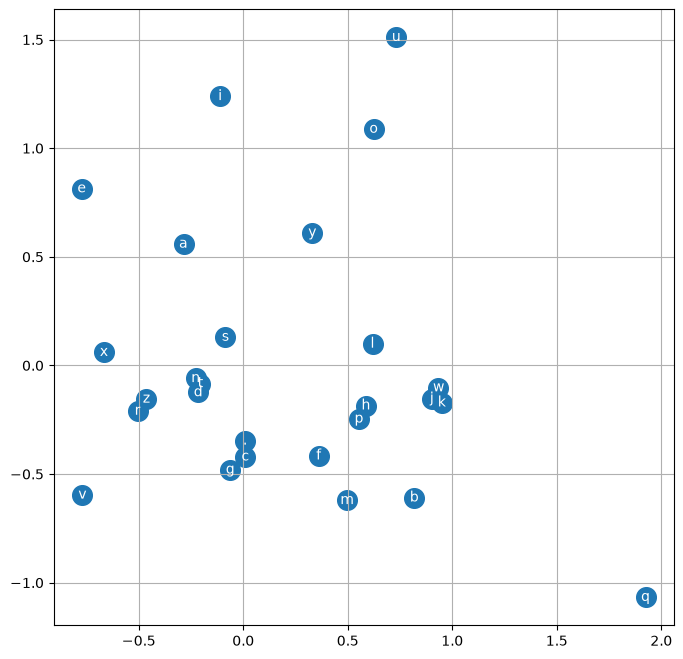

In [85]:
plt.figure(figsize=(8,8))
plt.scatter(C[:,0].data, C[:,1].data, s=200)
for i in range(C.shape[0]):
    plt.text(C[i,0].item(), C[i,1].item(), itos[i], ha="center", va="center", color='white')
plt.grid('minor')